In [2]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [4]:
data = {
    "Maths": [95, 88, 92, 70, 68, 75, 45, 50, 40, 60],
    "Science": [90, 85, 94, 72, 65, 78, 50, 55, 42, 58],    #the data is different
    "English": [60, 65, 62, 80, 82, 75, 88, 84, 90, 70],
    "Hindi": [58, 63, 60, 78, 72, 85, 72, 90, 82, 88]
}

df = pd.DataFrame(data)
print(df)

   Maths  Science  English  Hindi
0     95       90       60     58
1     88       85       65     63
2     92       94       62     60
3     70       72       80     78
4     68       65       82     72
5     75       78       75     85
6     45       50       88     72
7     50       55       84     90
8     40       42       90     82
9     60       58       70     88


In [5]:
#Display covariance matrix
print("Covariance Matrix: ")
cov_matrix = df.cov()
print(cov_matrix)

Covariance Matrix: 
              Maths     Science     English       Hindi
Maths    384.233333  343.255556 -194.422222 -164.822222
Science  343.255556  314.988889 -170.600000 -144.244444
English -194.422222 -170.600000  118.266667   77.911111
Hindi   -164.822222 -144.244444   77.911111  136.400000


In [6]:
#Add a "result" columns
df['Result'] = ((df['Maths'] >= 60) | (df['Science'] >= 60)) & ((df['English'] >= 60) | (df['Hindi'] >= 60)).astype(int)
print(df)

   Maths  Science  English  Hindi  Result
0     95       90       60     58    True
1     88       85       65     63    True
2     92       94       62     60    True
3     70       72       80     78    True
4     68       65       82     72    True
5     75       78       75     85    True
6     45       50       88     72   False
7     50       55       84     90   False
8     40       42       90     82   False
9     60       58       70     88    True


In [7]:
#Save tp csv(optional)
df.to_csv("strudent_marks.csv", index=False)


In [12]:
#2. Pca + logiistice Regression
numerical_cols = ['Maths', 'Science', 'English', 'Hindi']

In [13]:
#3 Handle missing values
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(df[numerical_cols])
data_clear = pd.DataFrame(data_imputed, columns=numerical_cols)

In [14]:
#4 Standardize
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_clear)

In [15]:
#5 Apply PCA
pca = PCA(n_components=4)
data_pca = pca.fit_transform(data_scaled)

In [19]:
#6 Explained_variance
explained_variance = pca.explained_variance_ratio_
cummulative_variance = np.cumsum(explained_variance)

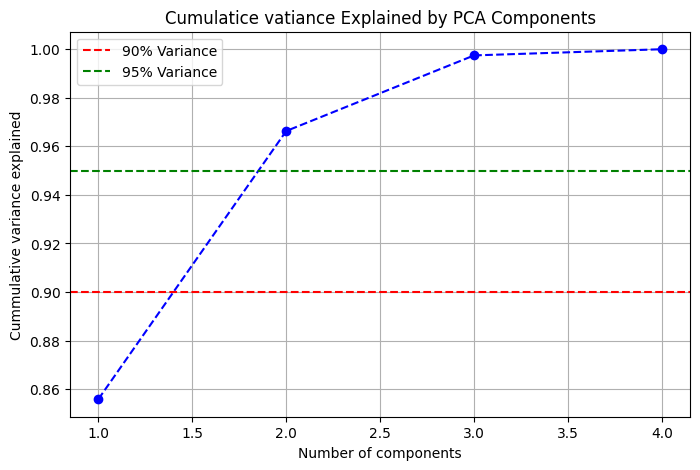

In [20]:
#7 plot cumulatice variannce
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cummulative_variance) + 1), cummulative_variance, marker = 'o', linestyle='--', color = 'b')
plt.title("Cumulatice vatiance Explained by PCA Components")
plt.xlabel('Number of components')
plt.ylabel("Cummulative variance explained")
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Variance')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
#8 Print variance ingo
print("Explained Variance Ratio(each PC shows hwo much info iot captures): ")
print(explained_variance.round(3))

print("cummulative_variance (how much total info is captured: )")
print(cummulative_variance.round(3))

Explained Variance Ratio(each PC shows hwo much info iot captures): 
[0.856 0.11  0.031 0.003]
cummulative_variance (how much total info is captured: )
[0.856 0.966 0.997 1.   ]


In [22]:
#9 Find feature contrubution (loadings)
#Loading tell ushow each original featuer contrinutes to each principal component
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=numerical_cols
)

print("Feature loadings (importeance of each feature in each component)")
print(loadings)

Feature loadings (importeance of each feature in each component)
              PC1       PC2       PC3       PC4
Maths    0.531938  0.171976  0.313422  0.767615
Science  0.524719  0.196692  0.539865 -0.628114
English -0.501852 -0.381793  0.766761  0.120234
Hindi   -0.435725  0.886550  0.149631  0.042229


In [31]:
# Add-on; Logistic Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
df

,Maths,Science,English,Hindi,Result
0,95,90,60,58,True
1,88,85,65,63,True
2,92,94,62,60,True
3,70,72,80,78,True
4,68,65,82,72,True
5,75,78,75,85,True
6,45,50,88,72,False
7,50,55,84,90,False
8,40,42,90,82,False
9,60,58,70,88,True


In [28]:
#10 Select Optimal Nuber of Components (eg., for 95% variance)
#find the index fo the first component where cumulatice vavriance is >= 0.95
index_of_95 = np.argmax(cummulative_variance >= 0.95)

#np.argmax retuens the index fo the first 'true'. If no true is found it retuns 0 
#we must check if the 95% target was actually reached at that index.
if cummulative_variance[index_of_95] >= 0.95:
    n_opt = index_of_95 + 1
else:
    #If the ratget was not reached, use all available components
    n_opt = len(explained_variance)

print("Optimal number of components to retain 95% variance: {n_opt}")

#use the optimally reduced data for modeling
X_pca_reduced = data_pca[::n_opt]

Optimal number of components to retain 95% variance: {n_opt}


In [32]:

#11. Prepare Data and Model
y = df['Result']
# ensure X_pca_reduced uses the first n_opt principal components (not row subsampling)
X_pca_reduced = data_pca[:, :n_opt]
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca_reduced, y, test_size=0.3, random_state=42, stratify=y)